# Funnel Stage Prediction — Model Training

**Problem type:** Multi-class classification (4 funnel stages)  
**Target variable:** `funnel_stage`  
0 = Browsing · 1 = Abandoned · 2 = Interested · 3 = Converted

**Models trained:**
- Logistic Regression (multinomial, baseline)
- Random Forest (ensemble, handles non-linearity)
- XGBoost (gradient boosting, primary model)

**Evaluation strategy:**
- 80/20 stratified train/test split
- 5-fold stratified cross-validation
- Metrics: weighted ROC-AUC (OvR), F1-score, confusion matrix

> Install dependencies before running:  
> `pip install scikit-learn xgboost matplotlib seaborn`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE  = 42
STAGE_LABELS  = ['Browsing', 'Abandoned', 'Interested', 'Converted']
STAGE_PALETTE = ['#6c757d', '#dc3545', '#fd7e14', '#198754']  # grey / red / orange / green

In [3]:
%run feature_engineering.ipynb

=== Strategy A — Binary label (baseline) ===
             Metric   Value
        Total Users 1350.00
    Converted Users  821.00
      Not Converted  529.00
Conversion Rate (%)   60.81

=== Strategy B — Funnel stage label (primary) ===
 Stage      Label  Users  Pct (%)
     0   Browsing    461     34.1
     1  Abandoned     79      5.9
     2 Interested    516     38.2
     3  Converted    294     21.8

  Score distribution (before collapsing):
    Score 0:  461 users (34.1%)  ██████████
    Score 1:   79 users ( 5.9%)  █
    Score 2:  516 users (38.2%)  ███████████
    Score 3:  268 users (19.9%)  █████
    Score 4:   26 users ( 1.9%)  

=== Feature Matrix ===
Shape : 1350 users  x  67 features

  Journey stats   : 3 features
  Page presence   : 14 features
  Page counts     : 14 features
  Entry page      : 14 features
  Exit page       : 14 features
  Sequence/signals: 8 features

=== Data quality checks ===
  Nulls in X                   : 0
  Nulls in y                   : 0
  Dty

In [4]:
# ── Build the full feature matrix ─────────────────────────────────────────────

raw_data = pd.read_csv('user_journey_raw.csv')

subscription_map = (
    raw_data.groupby('user_id')['subscription_type']
    .first().reset_index()
)

grouped_data = group_by(raw_data)
grouped_data = grouped_data.merge(subscription_map, on='user_id', how='left')
cleaned_data = remove_page_duplicates(grouped_data, 'user_journey')
labeled_data = label_funnel_stage(cleaned_data)

X, y, feature_names = get_funnel_matrix(labeled_data)

print('Dataset ready:')
print(f'  X shape        : {X.shape}')
print(f'  y distribution :')
for stage, label in FUNNEL_STAGE_NAMES.items():
    n = (y == stage).sum()
    print(f'    Stage {stage} ({label:<10}): {n:>4} users  ({n/len(y)*100:.1f}%)')

Dataset ready:
  X shape        : (1350, 67)
  y distribution :
    Stage 0 (Browsing  ):  461 users  (34.1%)
    Stage 1 (Abandoned ):   79 users  (5.9%)
    Stage 2 (Interested):  516 users  (38.2%)
    Stage 3 (Converted ):  294 users  (21.8%)


## 1 · Train / Test Split

Stratified split preserves the class proportions in both sets.  
We use 80/20 — standard for 1,350-row datasets.  
Logistic Regression additionally requires scaled features (mean=0, std=1).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = y          # preserves class balance in both splits
)

# Scale features for Logistic Regression
# Tree-based models (RF, XGB) don't need scaling — trained on raw X
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # apply same params to test

print(f'Train : {X_train.shape[0]} users')
print(f'Test  : {X_test.shape[0]} users')
print()
print('Class distribution check (should match overall ~34/6/38/22%):')
for stage, label in FUNNEL_STAGE_NAMES.items():
    tr = (y_train == stage).sum()
    te = (y_test  == stage).sum()
    print(f'  Stage {stage} ({label:<10}): train={tr}  test={te}')

Train : 1080 users
Test  : 270 users

Class distribution check (should match overall ~34/6/38/22%):
  Stage 0 (Browsing  ): train=369  test=92
  Stage 1 (Abandoned ): train=63  test=16
  Stage 2 (Interested): train=413  test=103
  Stage 3 (Converted ): train=235  test=59


## 2 · Model Definitions

Key hyperparameter choices:

| Model | Key setting | Why |
|---|---|---|
| Logistic Regression | `class_weight='balanced'` | Compensates for class imbalance (Abandoned only 6%) |
| Random Forest | `class_weight='balanced'` | Same reason; `n_estimators=200` for stability |
| XGBoost | `objective='multi:softprob'` | Returns class probabilities needed for ROC-AUC |

In [6]:
models = {
    'Logistic Regression': (
        LogisticRegression(
            max_iter     = 1000,
            class_weight = 'balanced',
            solver       = 'lbfgs',
            random_state = RANDOM_STATE,
        ),
        X_train_scaled,   # LR uses scaled features
        X_test_scaled,
    ),
    'Random Forest': (
        RandomForestClassifier(
            n_estimators = 200,
            max_depth    = None,
            class_weight = 'balanced',
            random_state = RANDOM_STATE,
            n_jobs       = -1,
        ),
        X_train, X_test,  # tree models use raw features
    ),
    'XGBoost': (
        XGBClassifier(
            objective        = 'multi:softprob',
            num_class        = 4,
            n_estimators     = 200,
            learning_rate    = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            eval_metric      = 'mlogloss',
            random_state     = RANDOM_STATE,
        ),
        X_train, X_test,
    ),
}

print('Models defined:', list(models.keys()))

Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 3 · Training & Evaluation

In [7]:
results = {}

for name, (model, Xtr, Xte) in models.items():

    # ── Train ────────────────────────────────────────────────────────────────
    model.fit(Xtr, y_train)

    # ── Predict ──────────────────────────────────────────────────────────────
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)   # shape (n_test, 4)

    # ── Metrics ──────────────────────────────────────────────────────────────
    roc_auc = roc_auc_score(
        y_test, y_prob,
        multi_class = 'ovr',        # One-vs-Rest
        average     = 'weighted'    # weighted by class support
    )

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'roc_auc' : roc_auc,
        'cm'      : confusion_matrix(y_test, y_pred),
        'report'  : classification_report(
                        y_test, y_pred,
                        target_names = STAGE_LABELS,
                        digits       = 3
                    )
    }

    print('=' * 62)
    print(f'  {name}')
    print('=' * 62)
    print(f'  ROC-AUC (OvR weighted) : {roc_auc:.4f}')
    print()
    print(results[name]['report'])

  Logistic Regression
  ROC-AUC (OvR weighted) : 0.9723

              precision    recall  f1-score   support

    Browsing      0.965     0.902     0.933        92
   Abandoned      0.429     0.750     0.545        16
  Interested      0.947     0.874     0.909       103
   Converted      0.934     0.966     0.950        59

    accuracy                          0.896       270
   macro avg      0.819     0.873     0.834       270
weighted avg      0.920     0.896     0.904       270

  Random Forest
  ROC-AUC (OvR weighted) : 0.9446

              precision    recall  f1-score   support

    Browsing      0.874     0.826     0.849        92
   Abandoned      0.417     0.312     0.357        16
  Interested      0.737     0.816     0.774       103
   Converted      0.737     0.712     0.724        59

    accuracy                          0.767       270
   macro avg      0.691     0.666     0.676       270
weighted avg      0.764     0.767     0.764       270

  XGBoost
  ROC-AUC (O

## 4 · Cross-Validation

5-fold stratified CV gives a more reliable estimate than a single train/test split.  
We report mean ± std ROC-AUC across folds.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('5-Fold Stratified Cross-Validation — ROC-AUC (OvR weighted)\n')
cv_results = {}

for name, (model, Xtr, _) in models.items():
    scores = cross_val_score(
        model, Xtr, y_train,
        cv      = cv,
        scoring = 'roc_auc_ovr_weighted',
        n_jobs  = -1
    )
    cv_results[name] = scores
    print(f'  {name:<22}  {scores.mean():.4f}  ±  {scores.std():.4f}')
    print(f'  {" "*22}  folds: {[round(s,4) for s in scores]}')
    print()

5-Fold Stratified Cross-Validation — ROC-AUC (OvR weighted)

  Logistic Regression     0.9721  ±  0.0083
                          folds: [np.float64(0.975), np.float64(0.9773), np.float64(0.9783), np.float64(0.9558), np.float64(0.9739)]

  Random Forest           0.9407  ±  0.0095
                          folds: [np.float64(0.9265), np.float64(0.9416), np.float64(0.9419), np.float64(0.9373), np.float64(0.9561)]

  XGBoost                 0.9620  ±  0.0062
                          folds: [np.float64(0.9597), np.float64(0.9621), np.float64(0.9624), np.float64(0.9533), np.float64(0.9726)]



## 5 · Confusion Matrices

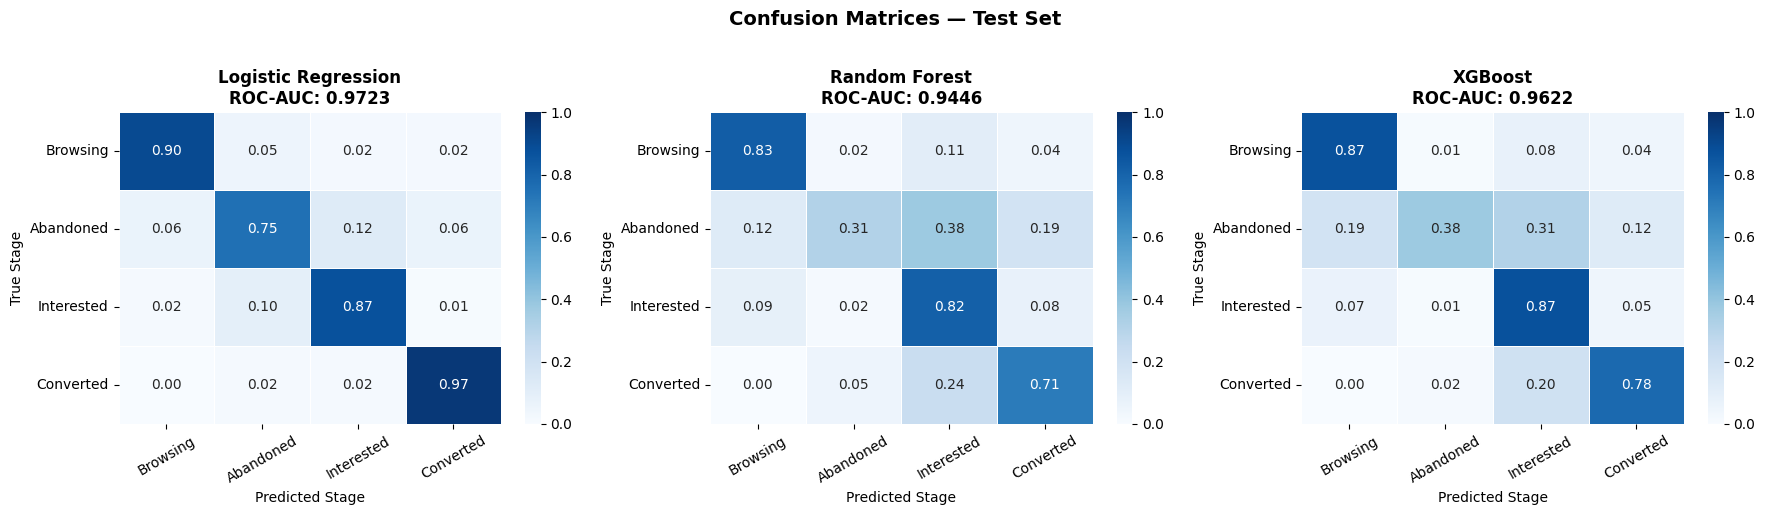

Saved: confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)

for ax, (name, res) in zip(axes, results.items()):
    cm_norm = res['cm'].astype('float') / res['cm'].sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot      = True,
        fmt        = '.2f',
        cmap       = 'Blues',
        xticklabels = STAGE_LABELS,
        yticklabels = STAGE_LABELS,
        ax         = ax,
        vmin=0, vmax=1,
        linewidths = 0.5
    )
    ax.set_title(f'{name}\nROC-AUC: {res["roc_auc"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted Stage')
    ax.set_ylabel('True Stage')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

## 6 · ROC-AUC Curves (One-vs-Rest per stage)

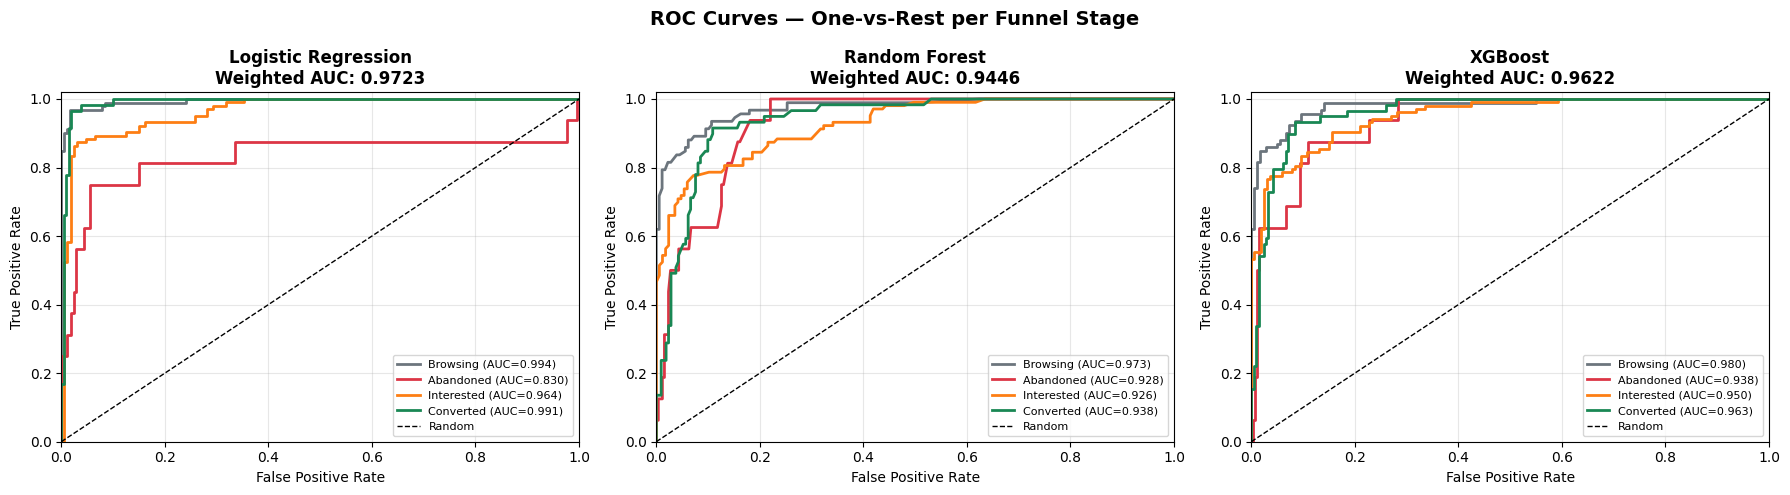

Saved: roc_curves.png


In [10]:
from sklearn.metrics       import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # (n_test, 4)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves — One-vs-Rest per Funnel Stage', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    for i, (label, color) in enumerate(zip(STAGE_LABELS, STAGE_PALETTE)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], res['y_prob'][:, i])
        stage_auc   = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{label} (AUC={stage_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_title(f'{name}\nWeighted AUC: {res["roc_auc"]:.4f}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

## 7 · Feature Importance

- **Logistic Regression:** mean absolute coefficient across classes (relative feature weight)
- **Random Forest:** mean decrease in impurity (Gini importance)
- **XGBoost:** mean gain — reduction in loss from splits on each feature

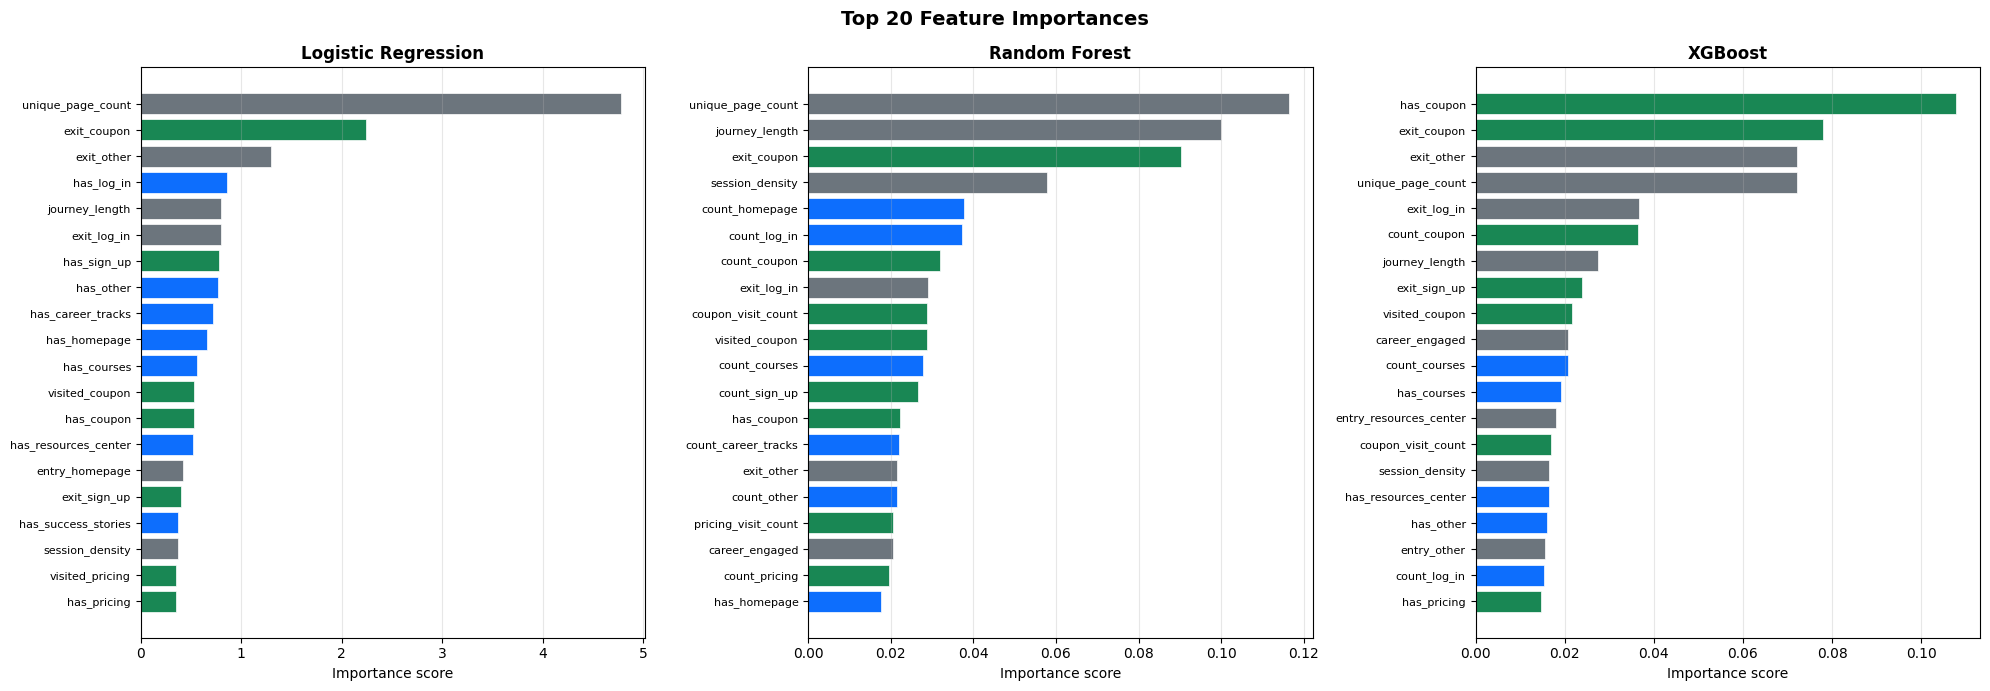

Saved: feature_importance.png


In [11]:
TOP_N = 20

def get_importances(model_name, model):
    """Extract feature importances in a unified format."""
    if model_name == 'Logistic Regression':
        # coef_ shape: (n_classes, n_features) — average absolute value across classes
        importance = np.abs(model.coef_).mean(axis=0)
    else:
        importance = model.feature_importances_
    return pd.Series(importance, index=feature_names).sort_values(ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'Top {TOP_N} Feature Importances', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    imp = get_importances(name, res['model']).head(TOP_N)

    colors = ['#198754' if 'pricing' in f or 'coupon' in f or 'sign_up' in f
              else '#0d6efd' if f.startswith('has_') or f.startswith('count_')
              else '#6c757d'
              for f in imp.index]

    ax.barh(range(len(imp)), imp.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## 8 · Model Comparison Summary

In [12]:
from sklearn.metrics import accuracy_score, f1_score

rows = []
for name, res in results.items():
    rows.append({
        'Model'              : name,
        'Test ROC-AUC'       : round(res['roc_auc'], 4),
        'CV ROC-AUC (mean)'  : round(cv_results[name].mean(), 4),
        'CV ROC-AUC (std)'   : round(cv_results[name].std(),  4),
        'Accuracy'           : round(accuracy_score(y_test, res['y_pred']), 4),
        'Weighted F1'        : round(f1_score(y_test, res['y_pred'], average='weighted'), 4),
        'Macro F1'           : round(f1_score(y_test, res['y_pred'], average='macro'),    4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')

print('=== Model Comparison ===')
print(summary_df.to_string())

best_model_name = summary_df['Test ROC-AUC'].idxmax()
best_auc        = summary_df.loc[best_model_name, 'Test ROC-AUC']
print(f'\nBest model: {best_model_name}  (ROC-AUC = {best_auc})')

# Save summary
summary_df.reset_index().to_csv('model_summary.csv', index=False)
print('Saved: model_summary.csv')

=== Model Comparison ===
                     Test ROC-AUC  CV ROC-AUC (mean)  CV ROC-AUC (std)  Accuracy  Weighted F1  Macro F1
Model                                                                                                  
Logistic Regression        0.9723             0.9721            0.0083    0.8963       0.9045    0.8343
Random Forest              0.9446             0.9407            0.0095    0.7667       0.7641    0.6762
XGBoost                    0.9622             0.9620            0.0062    0.8222       0.8177    0.7454

Best model: Logistic Regression  (ROC-AUC = 0.9723)
Saved: model_summary.csv


## 9 · Best Model — Per-Stage Deep Dive

For the winning model, inspect precision/recall/F1 per funnel stage  
to understand where the model excels and where it struggles.  
Stage 1 (Abandoned) is the hardest — only 79 users, class imbalance.

In [13]:
best = results[best_model_name]

print(f'=== {best_model_name} — Full Report ===')
print(best['report'])

# Per-stage probability calibration check
# For each true stage, show the average predicted probability for that stage
print('\nCalibration check (avg predicted probability for each true stage):')
print('(Diagonal values close to 1 = well-calibrated, high confidence)\n')
prob_df = pd.DataFrame(best['y_prob'], columns=[f'P({l})' for l in STAGE_LABELS])
prob_df['true_stage'] = y_test.values
calib   = prob_df.groupby('true_stage').mean().round(3)
calib.index = [STAGE_LABELS[i] for i in calib.index]
print(calib.to_string())

=== Logistic Regression — Full Report ===
              precision    recall  f1-score   support

    Browsing      0.965     0.902     0.933        92
   Abandoned      0.429     0.750     0.545        16
  Interested      0.947     0.874     0.909       103
   Converted      0.934     0.966     0.950        59

    accuracy                          0.896       270
   macro avg      0.819     0.873     0.834       270
weighted avg      0.920     0.896     0.904       270


Calibration check (avg predicted probability for each true stage):
(Diagonal values close to 1 = well-calibrated, high confidence)

            P(Browsing)  P(Abandoned)  P(Interested)  P(Converted)
Browsing          0.853         0.078          0.051         0.017
Abandoned         0.092         0.577          0.217         0.114
Interested        0.028         0.081          0.811         0.080
Converted         0.000         0.037          0.102         0.861


## 10 · Save Model Artifact

Serialise the best model, its scaler, and metadata into a single `.joblib` file.  
The Flask API loads this one file at startup — no retraining needed.

We save everything together so training and inference are guaranteed to use
identical preprocessing. If the scaler were saved separately and lost,
inference features would be on the wrong scale and predictions would be wrong.


In [14]:
import joblib, os, json
from feature_utils import FUNNEL_STAGE_NAMES, STAGE_RECOMMENDATIONS, SAFE_PAGES, _col

# ── Assemble the artifact ──────────────────────────────────────────────────────
# Everything the Flask API needs at inference time in one object.
# Saving as a dict (not just the model) makes it easy to add fields later
# without breaking existing deployments.

best_model_obj   = results[best_model_name]['model']
best_roc_auc     = results[best_model_name]['roc_auc']

# Determine whether this model needs scaled input
needs_scaling = (best_model_name == 'Logistic Regression')

artifact = {
    'model':             best_model_obj,
    'scaler':            scaler if needs_scaling else None,
    'needs_scaling':     needs_scaling,
    'model_name':        best_model_name,
    'feature_names':     feature_names,
    'funnel_stage_names': FUNNEL_STAGE_NAMES,
    'stage_recommendations': STAGE_RECOMMENDATIONS,
    'test_roc_auc':      round(best_roc_auc, 4),
    'weighted_f1':       round(
        summary_df.loc[best_model_name, 'Weighted F1'], 4
    ),
}

# ── Save ───────────────────────────────────────────────────────────────────────
os.makedirs('model_artifacts', exist_ok=True)
artifact_path = 'model_artifacts/funnel_model.joblib'
joblib.dump(artifact, artifact_path)

print(f'Artifact saved  : {artifact_path}')
print(f'Model           : {best_model_name}')
print(f'Needs scaling   : {needs_scaling}')
print(f'Test ROC-AUC    : {artifact["test_roc_auc"]}')
print(f'Weighted F1     : {artifact["weighted_f1"]}')
print(f'Feature count   : {len(feature_names)}')
print(f'File size       : {os.path.getsize(artifact_path) / 1024:.1f} KB')

# ── Quick sanity check — reload and predict one sample ────────────────────────
loaded     = joblib.load(artifact_path)
sample_X   = X_test.iloc[[0]]

if loaded['needs_scaling']:
    sample_X_in = loaded['scaler'].transform(sample_X)
else:
    sample_X_in = sample_X

pred_stage = int(loaded['model'].predict(sample_X_in)[0])
pred_probs = loaded['model'].predict_proba(sample_X_in)[0]

print(f'\nSanity check — first test user:')
print(f'  True stage  : {y_test.iloc[0]}  ({FUNNEL_STAGE_NAMES[y_test.iloc[0]]})')
print(f'  Pred stage  : {pred_stage}  ({FUNNEL_STAGE_NAMES[pred_stage]})')
print(f'  Probs       : { {FUNNEL_STAGE_NAMES[i]: round(float(p),3) for i, p in enumerate(pred_probs)} }')
print('\nArtifact verified ✓  —  ready for Flask deployment')


Artifact saved  : model_artifacts/funnel_model.joblib
Model           : Logistic Regression
Needs scaling   : True
Test ROC-AUC    : 0.9723
Weighted F1     : 0.9045
Feature count   : 67
File size       : 7.9 KB

Sanity check — first test user:
  True stage  : 2  (Interested)
  Pred stage  : 2  (Interested)
  Probs       : {'Browsing': 0.012, 'Abandoned': 0.012, 'Interested': 0.93, 'Converted': 0.047}

Artifact verified ✓  —  ready for Flask deployment
